In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [3]:
df = pd.read_csv('concrete_data.csv')
df.sample(10)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
289,182.0,45.2,122.0,170.2,8.2,1059.4,780.7,3,7.32
178,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,91,76.80
443,194.7,0.0,100.5,170.2,7.5,998.0,901.8,28,37.27
846,366.0,187.0,0.0,191.0,7.0,824.0,757.0,28,65.91
501,491.0,26.0,123.0,210.0,3.9,882.0,699.0,3,25.61
546,333.0,0.0,0.0,192.0,0.0,931.2,842.6,28,31.97
201,190.7,0.0,125.4,162.1,7.8,1090.0,804.0,28,26.40
797,500.0,0.0,0.0,200.0,0.0,1125.0,613.0,180,51.04
255,212.5,0.0,100.4,159.3,8.7,1007.8,903.6,14,26.31
896,313.0,161.0,0.0,178.0,10.0,917.0,759.0,28,52.44


In [4]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [5]:
df.shape

(1030, 9)

In [6]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Strength']),df['Strength'],test_size=0.2,random_state=0)
x_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
741,480.0,0.0,0.0,192.0,0.0,936.0,721.0,28
638,375.0,0.0,0.0,186.0,0.0,1038.0,758.0,28
993,303.6,139.9,0.0,213.5,6.2,895.5,722.5,28
279,251.4,0.0,118.3,188.5,6.4,1028.4,757.7,3
796,500.0,0.0,0.0,200.0,0.0,1125.0,613.0,90
...,...,...,...,...,...,...,...,...
277,251.4,0.0,118.3,188.5,5.8,1028.4,757.7,56
763,385.0,0.0,0.0,186.0,0.0,966.0,763.0,1
835,144.0,0.0,175.0,158.0,18.0,943.0,844.0,28
559,239.6,359.4,0.0,185.7,0.0,941.6,664.3,28


In [8]:
lr = LinearRegression()

lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

r2_score(y_test,y_pred)

0.6369606518338298

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\2872129621.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[i])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\2872129621.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[i])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892

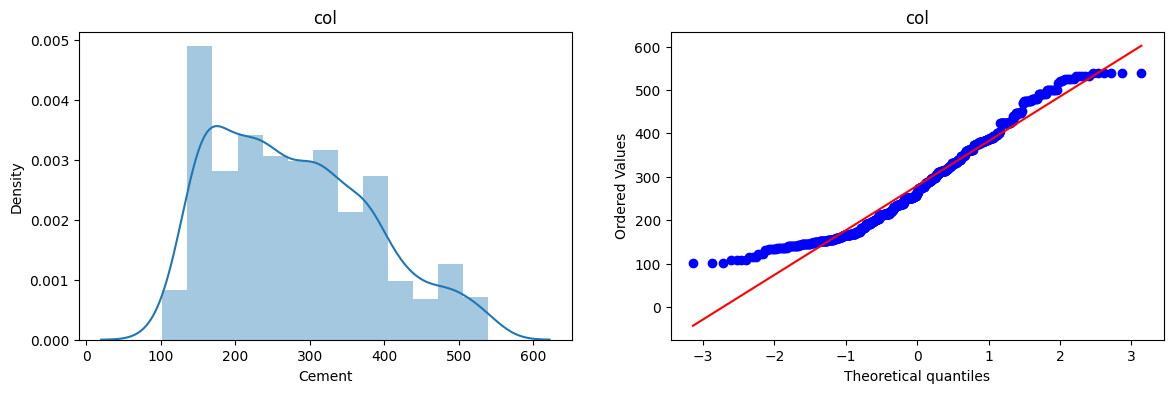

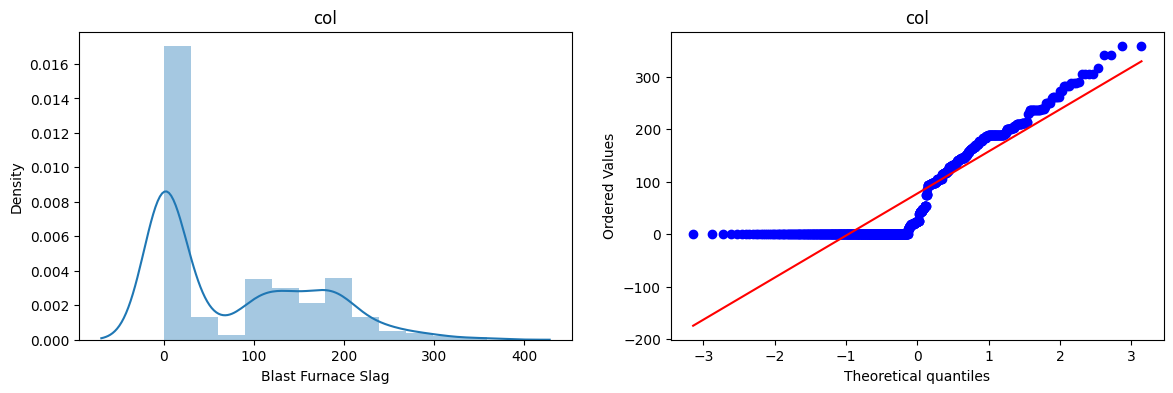

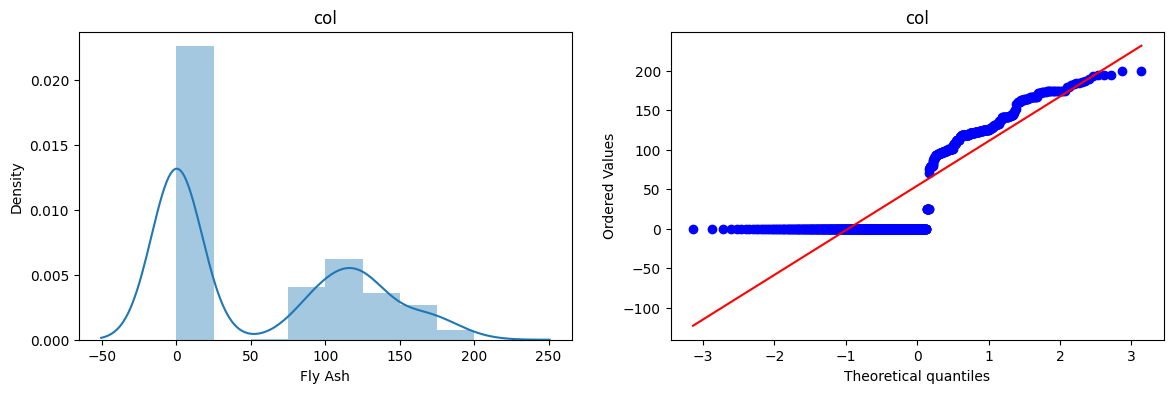

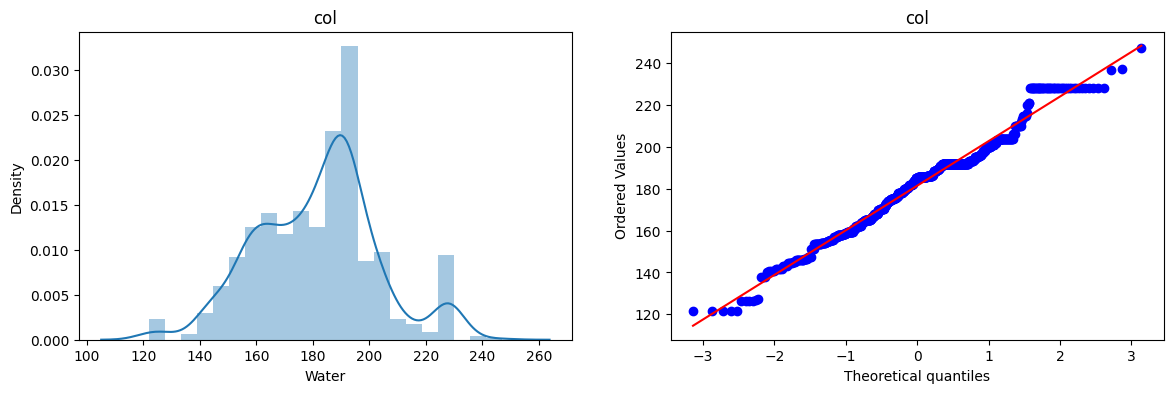

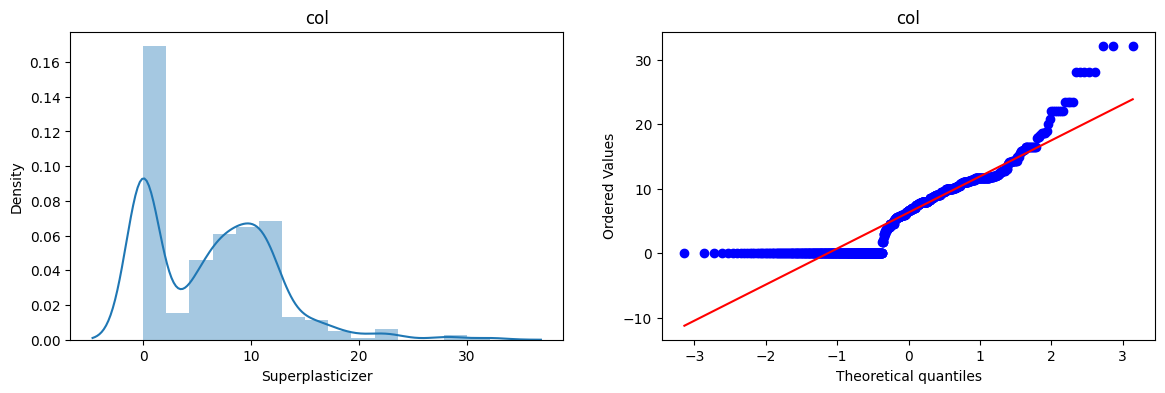

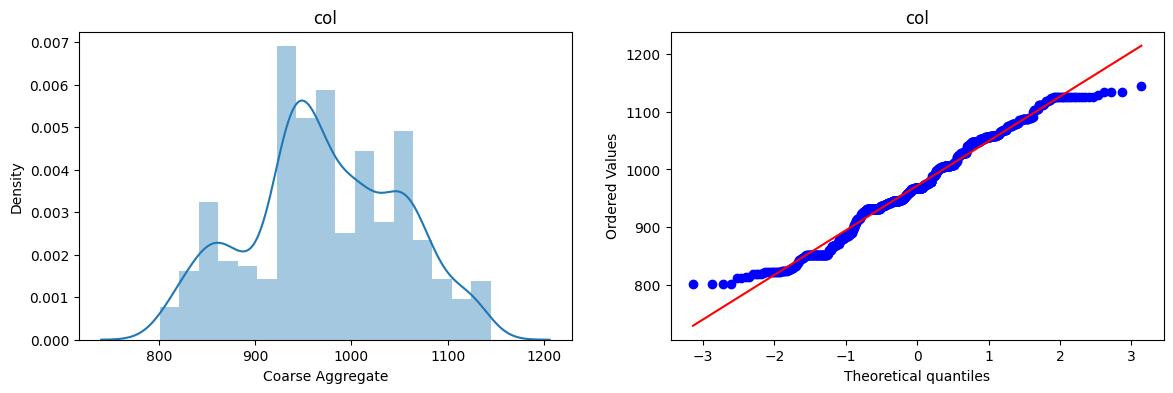

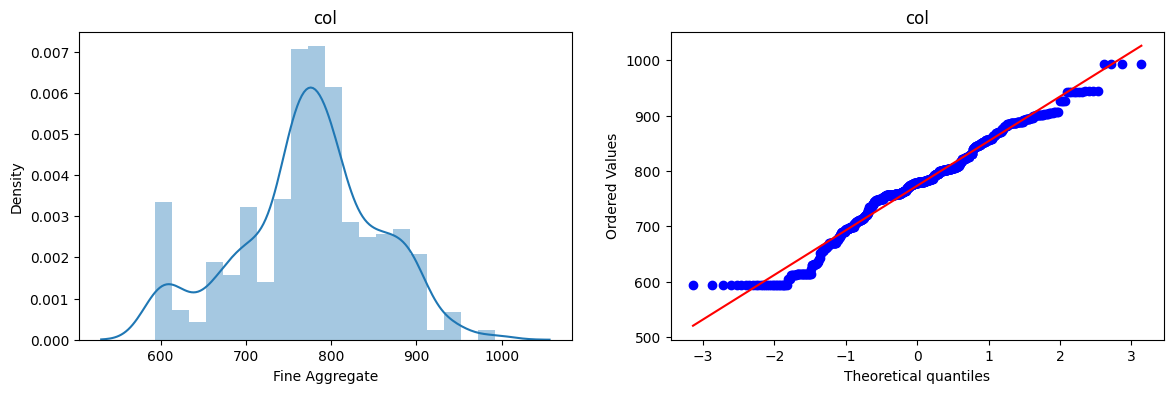

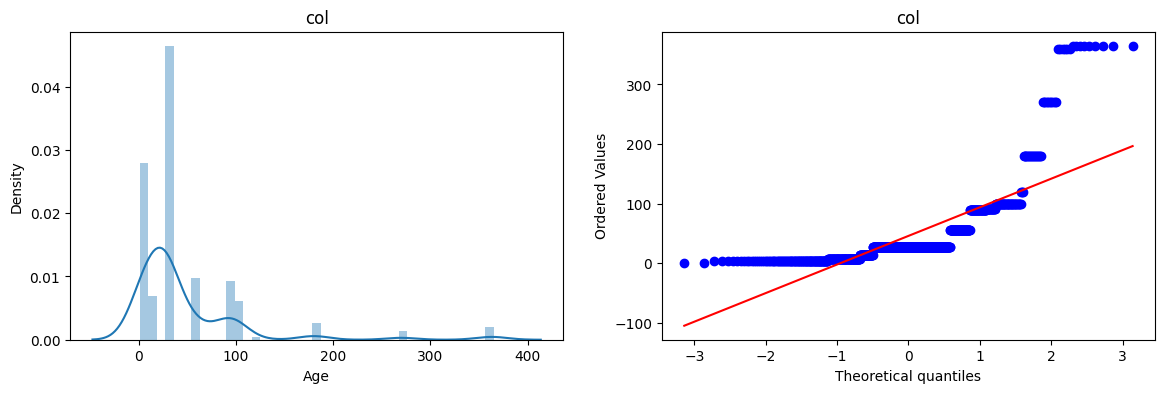

In [10]:
for i in x_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(x_train[i])
    plt.title('col')

    plt.subplot(122)
    stats.probplot(x_train[i], dist="norm", plot=plt)
    plt.title('col')

In [11]:
pow=PowerTransformer(method='box-cox')

x_train_trans=pow.fit_transform(x_train+000.1)
x_test_trans=pow.transform(x_test+000.1)

pd.DataFrame({'cols':x_train.columns,'box_cox_lambdas':pow.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.152770
1,Blast Furnace Slag,0.052480
2,Fly Ash,-0.092435
3,Water,0.888001
4,Superplasticizer,0.275673
5,Coarse Aggregate,1.115703
6,Fine Aggregate,1.789700
7,Age,0.058004


In [12]:
lr = LinearRegression()
lr.fit(x_train_trans,y_train)

y_pred2 = lr.predict(x_test_trans)

r2_score(y_test,y_pred2)

0.8203880742887943

In [13]:
pt = PowerTransformer(method='box-cox')
X_tr = pt.fit_transform((df.drop(columns=['Strength']))+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_tr,df['Strength'],scoring='r2'))

np.float64(0.6658537941434357)

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


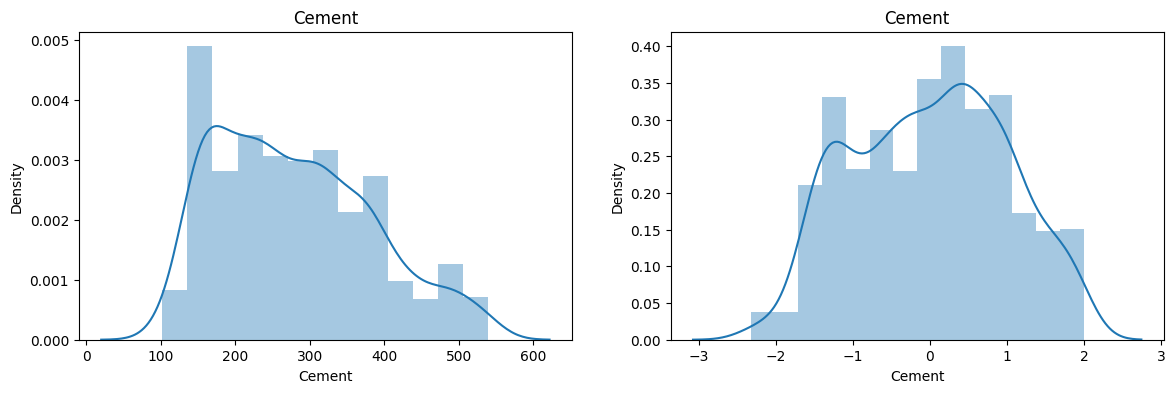

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


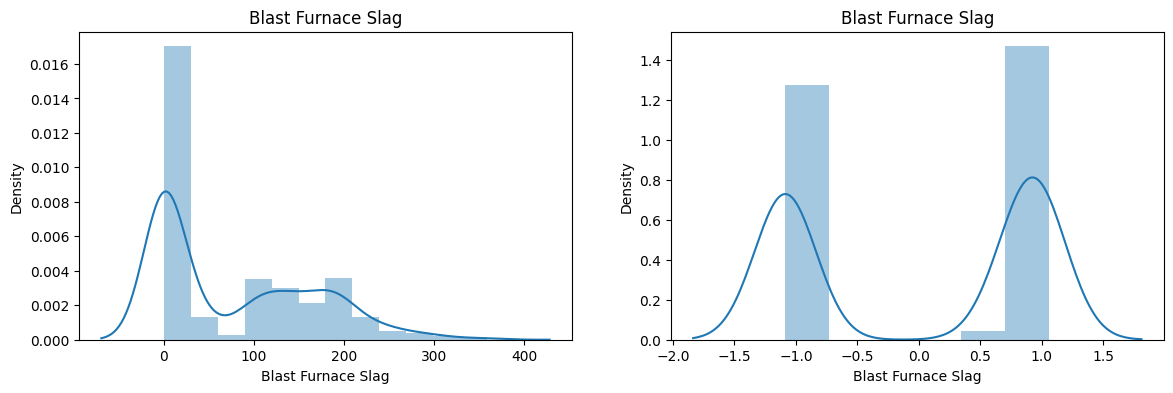

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


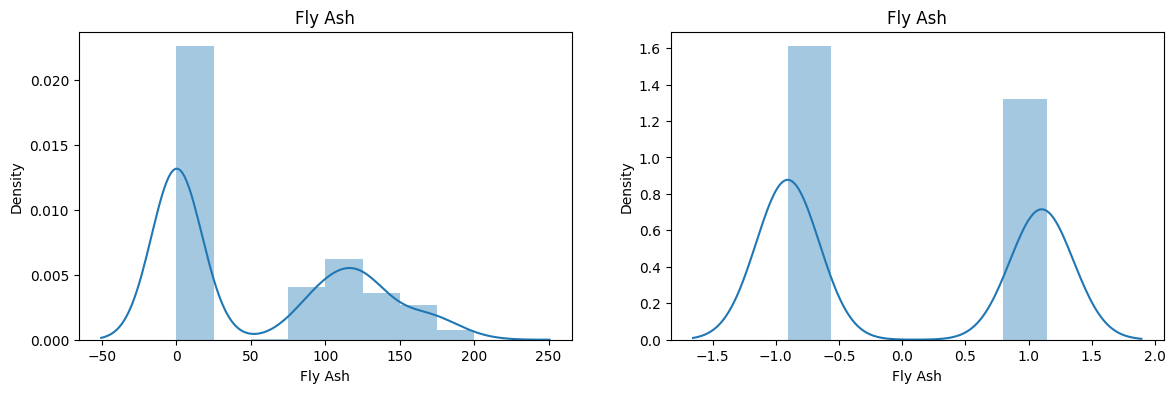

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


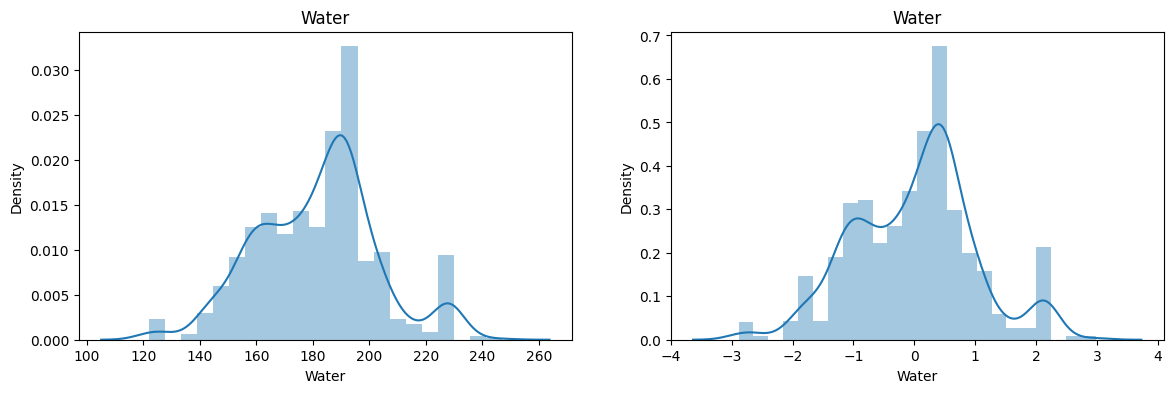

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


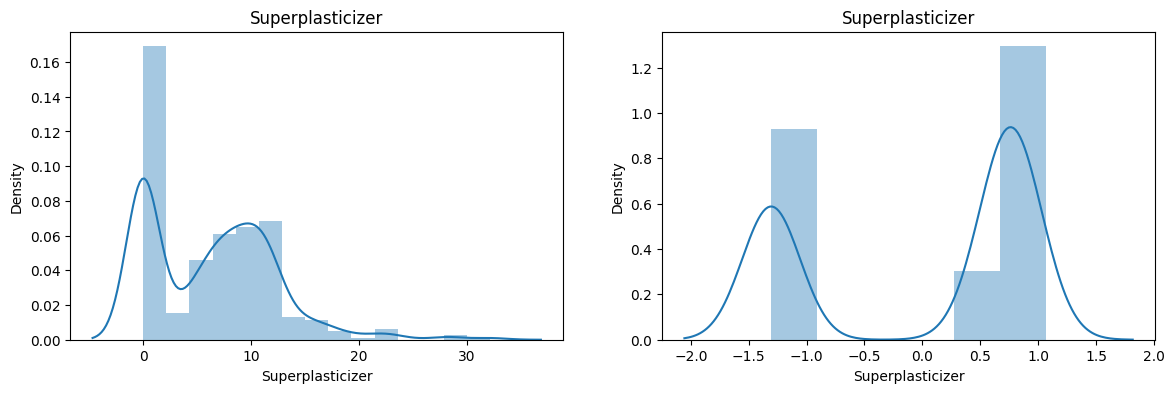

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


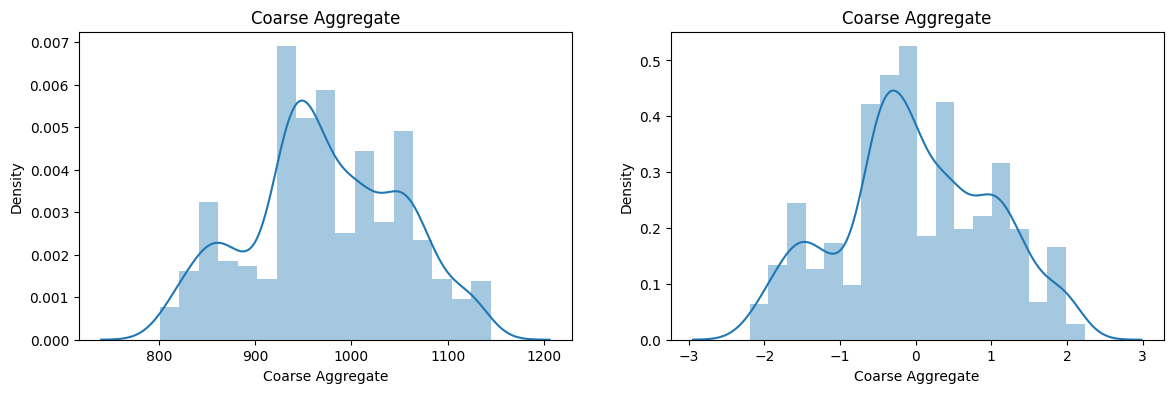

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


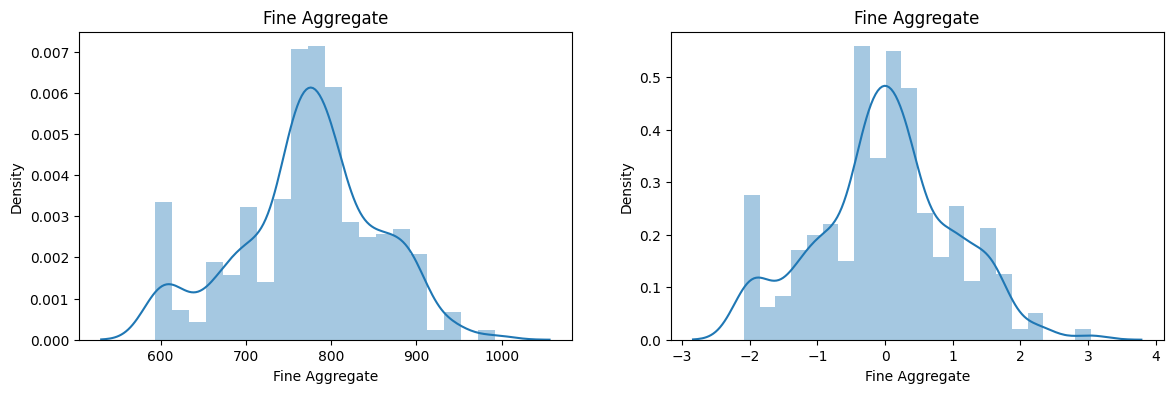

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\4099113659.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_transformed[col])


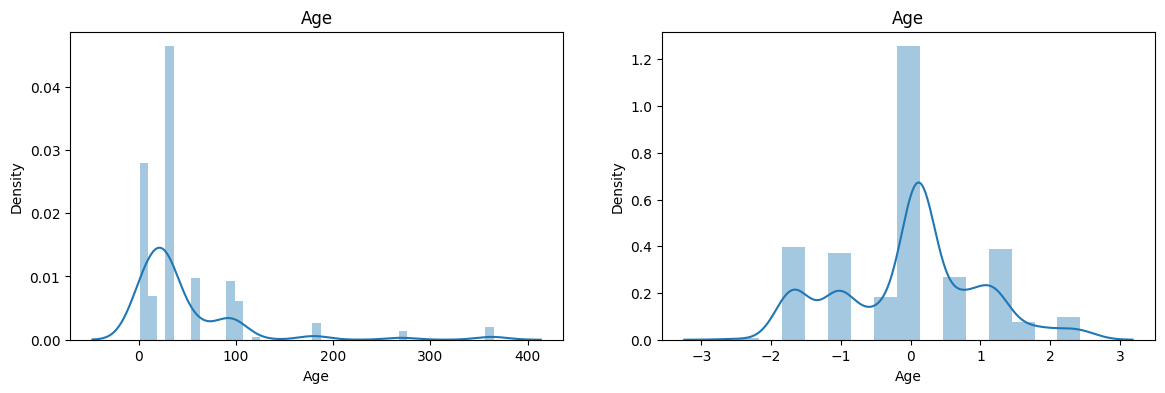

In [16]:
# Before and after comparision for Box-Cox Plot
X_train_transformed = pd.DataFrame(X_tr,columns=x_train.columns)

for col in X_train_transformed.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(X_train_transformed[col])
    plt.title(col)

    plt.show()

In [20]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

x_train_transformed2 = pt1.fit_transform(x_train)
x_test_transformed2 = pt1.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_transformed2,y_train)

y_pred3 = lr.predict(x_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':x_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8253744918217878


,cols,Yeo_Johnson_lambdas
0,Cement,0.150260
1,Blast Furnace Slag,0.038667
2,Fly Ash,-0.141876
3,Water,0.887369
4,Superplasticizer,0.293603
5,Coarse Aggregate,1.115901
6,Fine Aggregate,1.790678
7,Age,0.016397


In [23]:
# applying cross val score

pt = PowerTransformer()
x_transformed2 = pt.fit_transform(df.drop(columns=['Strength']))

lr = LinearRegression()
np.mean(cross_val_score(lr,x_transformed2,df['Strength'],scoring='r2'))

np.float64(0.6834625126992433)

C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\1786902011.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train[col])
C:\Users\mahad\AppData\Local\Temp\ipykernel_9892\1786902011.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_transformed2[col])
C:\Users\mahad\AppData\Local\T

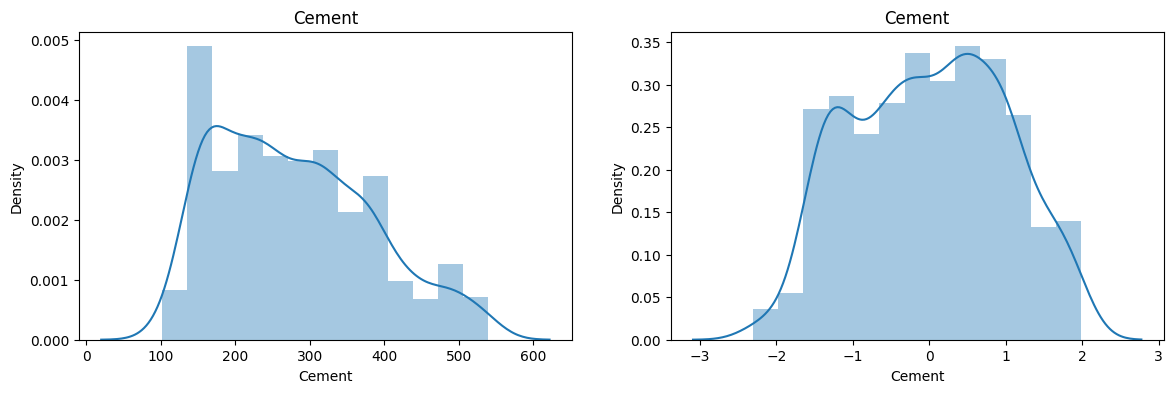

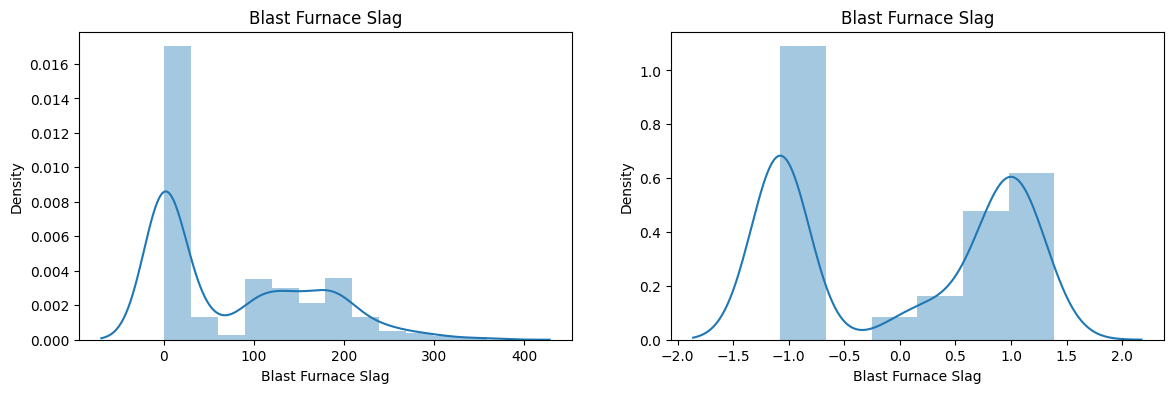

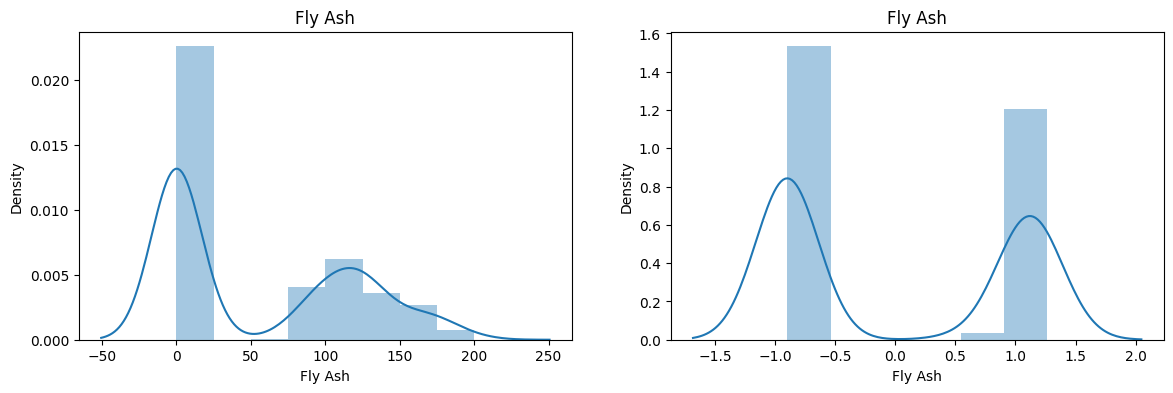

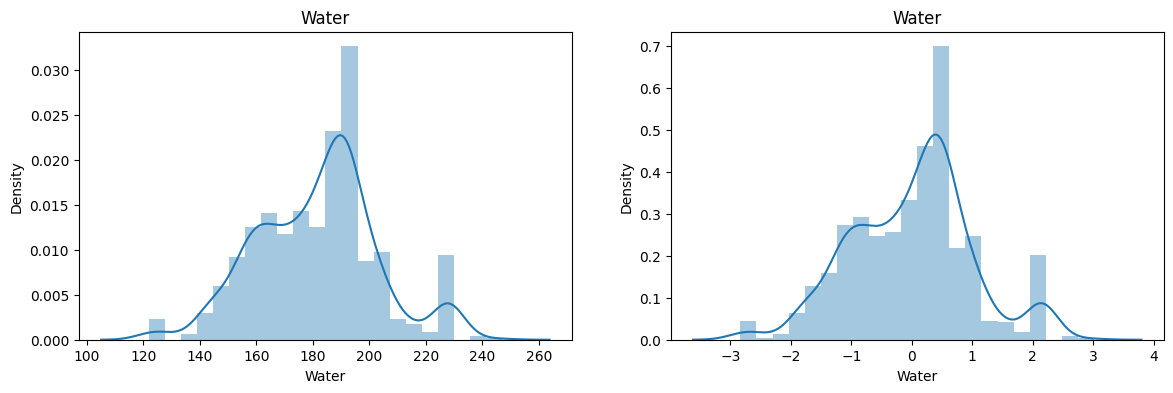

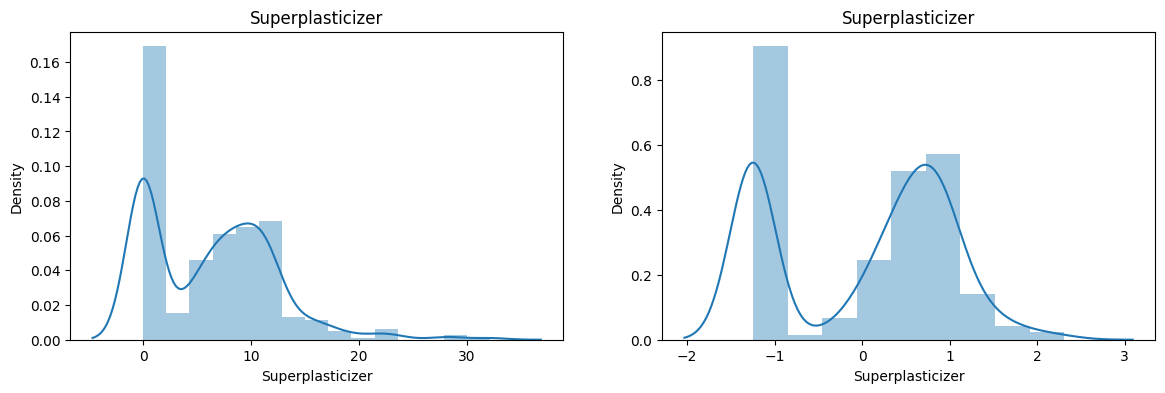

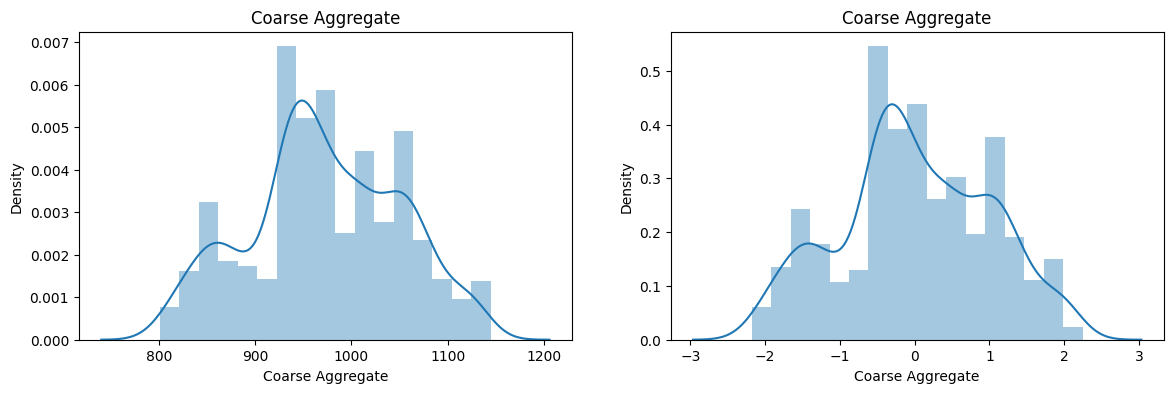

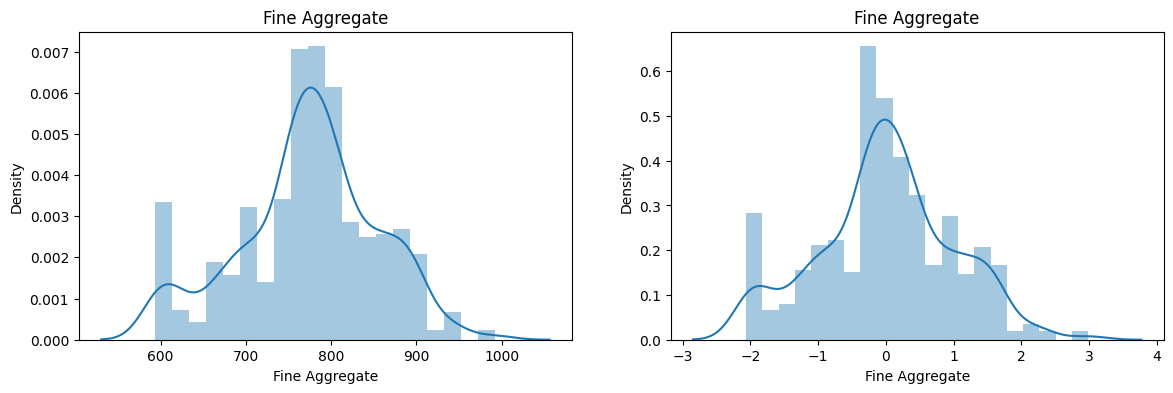

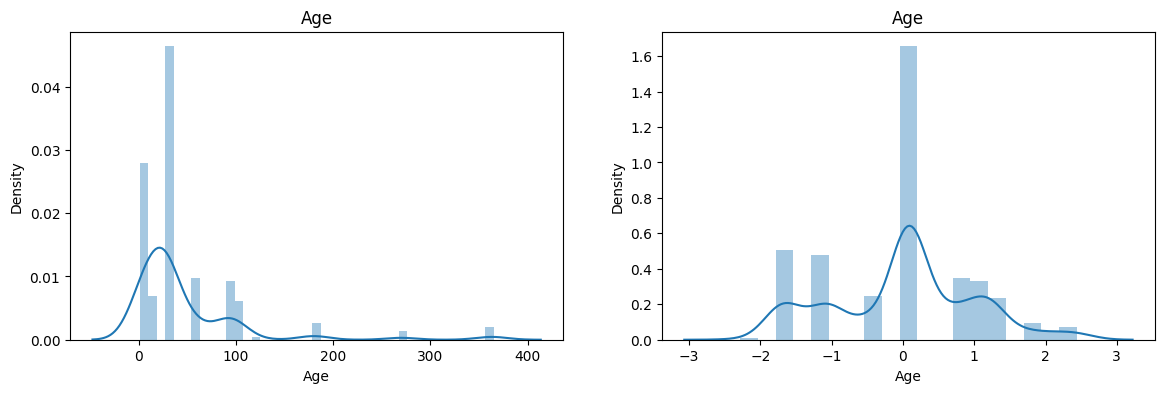

In [27]:
x_train_transformed2 = pd.DataFrame(x_train_transformed2,columns=x_train.columns)

for col in x_train_transformed2.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.distplot(x_train_transformed2[col])
    plt.title(col)